In [15]:
# Importar librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import *
import streamlit as st
import holidays

In [ ]:
# Instrucciones para la IA de Codex que siempre tiene que tener en cuenta a parte de la instrucción del usuario:

"""
⦁	empieza siempre tu respuesta con el emoji 🤖
⦁	responde siempre en español
⦁	recuerda que las variables del dataframe df que tienes que usar siempre en el codigo que generes son:

ventas:['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos']

competencia: ['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage']



⦁	no uses en tu codigo ninguna otra variable que no este en la lista anterior salvo que la hayas definido tu mismo en el codigo que generes
⦁	no uses ninguna libreria que no sean estas: pandas, numpy, matplotlib, seaborn, scikit-learn, jupyter, streamlit, holidays

"""

In [ ]:
# Cargar datos desde data/raw/entrenamiento
import pandas as pd
import os

# Paths relativos desde la carpeta notebooks
ventas_path = os.path.join('..','data','raw','entrenamiento','ventas.csv')
competencia_path = os.path.join('..','data','raw','entrenamiento','competencia.csv')

# cargar los archivos csv en dataframes

ventas = pd.read_csv('../data/raw/entrenamiento/ventas.csv')
competencia = pd.read_csv('../data/raw/entrenamiento/competencia.csv')

# Mostrar las primeras filas de los dataframes
print("--- ventas (primeras 5 filas) ---")
print(ventas.head())
print("\n--- competencia (primeras 5 filas) ---")
print(competencia.head())

## Informe de calidad de datos — `ventas`
Esta celda (siguiente) ejecuta comprobaciones automáticas sobre el dataframe `ventas`:
- Dimensiones y tipos de variables
- Valores nulos (absoluto y %), duplicados
- Estadísticos descriptivos para numéricos y categóricos
- Revisión de la columna `fecha` (parseo, rango)
- Resumen final con columnas problemáticas

In [24]:


# Tipos de datos por columna
ventas_dtypes = ventas.dtypes
print("Tipos de datos por columna:")
print(ventas_dtypes)
print("\n")
# Nulos y porcentaje
ventas_nulls = ventas.isnull().sum()
print("Número de valores nulos por columna:")
print(ventas_nulls)
print("\n")

# Duplicados (filas completas)
ventas_duplicates = ventas.duplicated().sum()
print("Nº valores duplicados?")
print(ventas_duplicates)
print("\n")

# Estadísticas descriptivas
ventas_describe = ventas.describe()
print("Estadísticas descriptivas:")
print(ventas_describe)
print("\n")


# Información general del DataFrame
ventas_info = ventas.info()
print("Información general del DataFrame:")
print(ventas_info)
print("\n")

#Resumen final


print("Número de valores nulos por columna:")
print(ventas.isnull().sum())
print("\n")

print("Nº valores duplicados?")
print(ventas.duplicated().sum())
print("\n")





Tipos de datos por columna:
fecha                 object
producto_id           object
nombre                object
categoria             object
subcategoria          object
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object


Número de valores nulos por columna:
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64


Nº valores duplicados?
0


Estadísticas descriptivas:
       precio_base  unidades_vendidas  precio_venta      ingresos
count  3552.000000         3552.00000   3552.000000   3552.000000
mean    123.125000            4.87866    121.816546    605.972323
std     165.576753            6.31102    164.017963   1079.071192
min      20.000000            1.00000     19.000000     19.460000


## Informe de calidad de datos — `competencia`
Esta celda (siguiente) ejecuta comprobaciones automáticas sobre el dataframe `competencia`:
- Dimensiones y tipos de variables
- Valores nulos (absoluto y %), duplicados
- Estadísticos descriptivos para numéricos y categóricos
- Revisión de la columna `fecha` (parseo, rango)
- Resumen final con columnas problemáticas


In [26]:
# Análisis de calidad de datos para 'competencia'

# Tipos de datos por columna
competencia_dtypes = competencia.dtypes
print("Tipos de datos por columna:")
print(competencia_dtypes)
print("\n")

# Nulos y porcentaje
competencia_nulls = competencia.isnull().sum()
print("Número de valores nulos por columna:")
print(competencia_nulls)
print("\n")

# Duplicados (filas completas)
competencia_duplicates = competencia.duplicated().sum()
print("Nº valores duplicados (filas completas)?")
print(competencia_duplicates)
print("\n")

# Estadísticas descriptivas
competencia_describe = competencia.describe()
print("Estadísticas descriptivas:")
print(competencia_describe)
print("\n")

# Información general del DataFrame
competencia_info = competencia.info()
print("Información general del DataFrame:")
print(competencia_info)
print("\n")

# Resumen final
print("--- Resumen final ---")
print(f"Dimensiones: {competencia.shape[0]} filas, {competencia.shape[1]} columnas")
print(f"Valores nulos por columna:\n{competencia.isnull().sum()}")
print(f"\nFilas duplicadas: {competencia_duplicates}")


Tipos de datos por columna:
fecha            object
producto_id      object
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object


Número de valores nulos por columna:
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64


Nº valores duplicados (filas completas)?
0


Estadísticas descriptivas:
            Amazon    Decathlon  Deporvillage
count  3552.000000  3552.000000   3552.000000
mean    118.623407   111.412182    118.894628
std     156.095628   148.508132    160.216448
min      16.850000    15.450000     16.770000
25%      47.117500    43.285000     47.310000
50%      73.180000    66.285000     72.700000
75%     114.342500   111.172500    114.985000
max     858.350000   867.337500    932.325000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fecha    

## Conversión de `fecha` a datetime
Convertir la columna `fecha` a tipo datetime en ambos dataframes para análisis temporal correcto.


In [29]:
# Convertir fecha a datetime en ambos dataframes
ventas['fecha'] = pd.to_datetime(ventas['fecha'])
competencia['fecha'] = pd.to_datetime(competencia['fecha'])

print(f"ventas fecha: {ventas['fecha'].dtype}, rango: {ventas['fecha'].min()} a {ventas['fecha'].max()}, NaT: {ventas['fecha'].isna().sum()}")
print(f"competencia fecha: {competencia['fecha'].dtype}, rango: {competencia['fecha'].min()} a {competencia['fecha'].max()}, NaT: {competencia['fecha'].isna().sum()}")
print("✓ Conversión completada.")

ventas fecha: datetime64[ns], rango: 2021-10-25 00:00:00 a 2024-11-30 00:00:00, NaT: 0
competencia fecha: datetime64[ns], rango: 2021-10-25 00:00:00 a 2024-11-30 00:00:00, NaT: 0
✓ Conversión completada.


In [30]:
# Validar conversión y mostrar ejemplos
print("="*70)
print("VALIDACIÓN DE CONVERSIÓN A DATETIME")
print("="*70)

print("\n--- VENTAS ---")
print(f"Tipo de 'fecha': {ventas['fecha'].dtype}")
print(f"Rango: {ventas['fecha'].min()} a {ventas['fecha'].max()}")
print(f"Días únicos: {ventas['fecha'].nunique()}")
print(f"\nPrimeras 5 filas con fechas:")
print(ventas[['fecha', 'nombre', 'precio_venta', 'ingresos']].head())

print("\n--- COMPETENCIA ---")
print(f"Tipo de 'fecha': {competencia['fecha'].dtype}")
print(f"Rango: {competencia['fecha'].min()} a {competencia['fecha'].max()}")
print(f"Días únicos: {competencia['fecha'].nunique()}")
print(f"\nPrimeras 5 filas con fechas:")
print(competencia[['fecha', 'producto_id', 'Amazon', 'Decathlon']].head())

print("\n" + "="*70)
print("✓ Todas las conversiones se realizaron correctamente.")
print("="*70)


VALIDACIÓN DE CONVERSIÓN A DATETIME

--- VENTAS ---
Tipo de 'fecha': datetime64[ns]
Rango: 2021-10-25 00:00:00 a 2024-11-30 00:00:00
Días únicos: 148

Primeras 5 filas con fechas:
       fecha                            nombre  precio_venta  ingresos
0 2021-10-25          Nike Air Zoom Pegasus 40        118.36    710.16
1 2021-10-25              Adidas Ultraboost 23        136.82   1368.20
2 2021-10-25               Asics Gel Nimbus 25         84.93    169.86
3 2021-10-25  New Balance Fresh Foam X 1080v12         75.42    150.84
4 2021-10-25                Nike Dri-FIT Miler         35.87     71.74

--- COMPETENCIA ---
Tipo de 'fecha': datetime64[ns]
Rango: 2021-10-25 00:00:00 a 2024-11-30 00:00:00
Días únicos: 148

Primeras 5 filas con fechas:
       fecha producto_id  Amazon  Decathlon
0 2021-10-25    PROD_001   82.96     111.88
1 2021-10-25    PROD_002  112.56     108.61
2 2021-10-25    PROD_003   79.79      78.44
3 2021-10-25    PROD_004   72.60      67.29
4 2021-10-25    PROD_005 

In [34]:
# Crear `dataframe_unified` mediante INNER JOIN por `fecha` y `producto_id`
import pandas as pd

dataframe_unified = pd.merge(
    ventas,
    competencia,
    how='inner',
    on=['fecha','producto_id']
)

print(dataframe_unified.head())


       fecha producto_id  ... Decathlon Deporvillage
0 2021-10-25    PROD_001  ...    111.88        97.43
1 2021-10-25    PROD_002  ...    108.61       115.58
2 2021-10-25    PROD_003  ...     78.44        80.11
3 2021-10-25    PROD_004  ...     67.29        74.45
4 2021-10-25    PROD_005  ...     33.60        33.07

[5 rows x 13 columns]


## Análisis exploratorio de `dataframe_unified`
A continuación se presentan diferentes análisis y visualizaciones sobre el dataframe unificado, utilizando `seaborn` para todos los gráficos.

Cada gráfico se acompaña de una breve explicación y se realiza en una celda separada para facilitar la interpretación.

In [ ]:
# 🤖 Análisis general del dataframe_unified
print('Dimensiones:', dataframe_unified.shape)
print('Columnas:', dataframe_unified.columns.tolist())
print('Primeras filas:')
print(dataframe_unified.head())
print('\nTipos de datos:')
print(dataframe_unified.dtypes)
print('\nValores nulos por columna:')
print(dataframe_unified.isnull().sum())
print('\nDuplicados:', dataframe_unified.duplicated().sum())
print('\nEstadísticas descriptivas:')
print(dataframe_unified.describe(include='all'))

### Suma de unidades vendidas por año (líneas temporales)
Se grafican las unidades vendidas por día, separando por año, y se marcan los días de Black Friday en cada año.

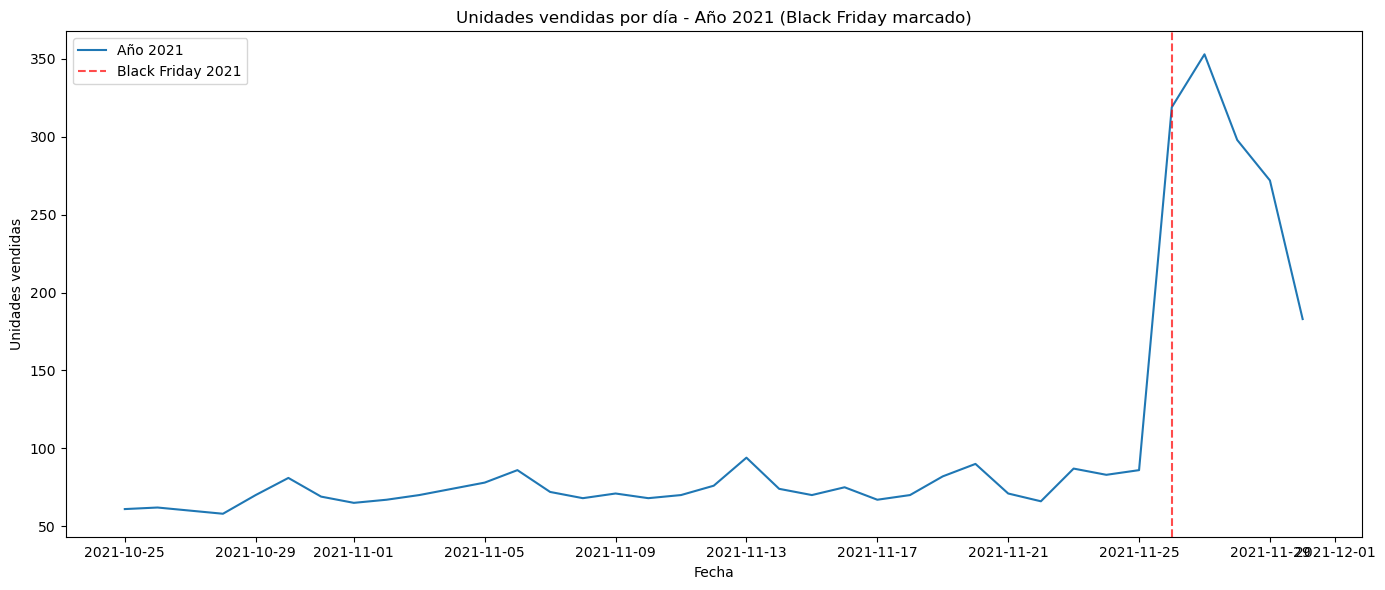

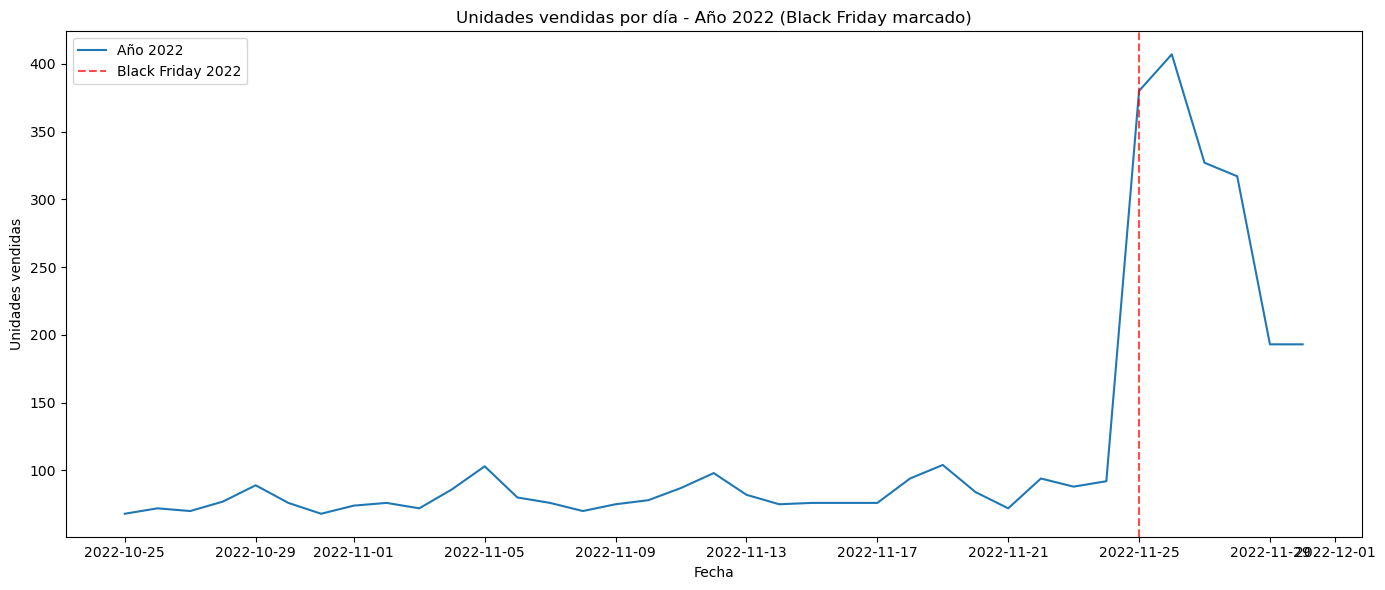

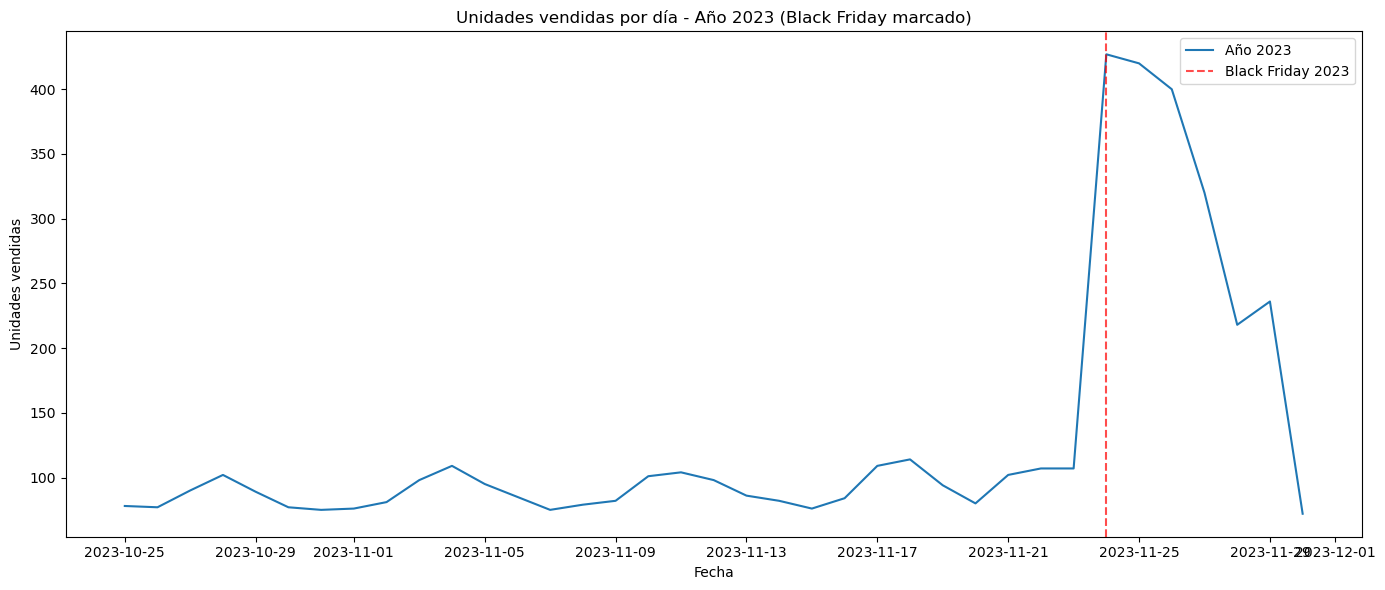

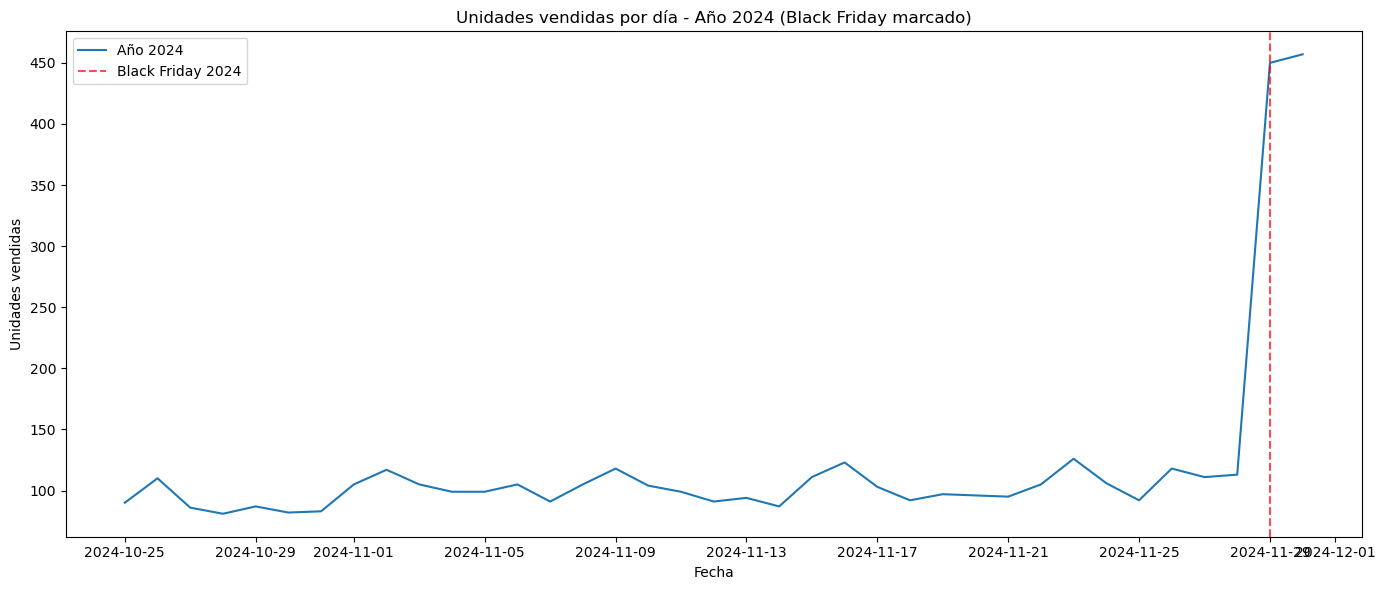

In [63]:
# 🤖 Gráfico de líneas temporales por año con Black Friday marcado (un gráfico por año)
import seaborn as sns
import matplotlib.pyplot as plt
df = dataframe_unified.copy()
df['año'] = df['fecha'].dt.year
df['dia'] = df['fecha'].dt.date
# Sumar unidades vendidas por día
ventas_por_dia = df.groupby(['dia','año'])['unidades_vendidas'].sum().reset_index()
# Identificar Black Friday (último viernes de noviembre)
def get_black_friday(year):
    nov = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
    fridays = [d for d in nov if d.weekday() == 4]
    return fridays[-1].date()
black_fridays = {a:get_black_friday(a) for a in ventas_por_dia['año'].unique()}
# Un gráfico por cada año
for año in ventas_por_dia['año'].unique():
    datos = ventas_por_dia[ventas_por_dia['año']==año]
    plt.figure(figsize=(14,6))
    sns.lineplot(x='dia', y='unidades_vendidas', data=datos, label=f'Año {año}')
    bf = black_fridays[año]
    plt.axvline(bf, color='red', linestyle='--', alpha=0.7, label=f'Black Friday {año}')
    plt.title(f'Unidades vendidas por día - Año {año} (Black Friday marcado)')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Suma de unidades vendidas por día de la semana
Visualización de la suma de unidades vendidas agrupadas por el día de la semana.

C:\Users\jorge\AppData\Local\Temp\ipykernel_8068\2727802638.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_dia_semana.index, y=ventas_por_dia_semana.values, palette='viridis')


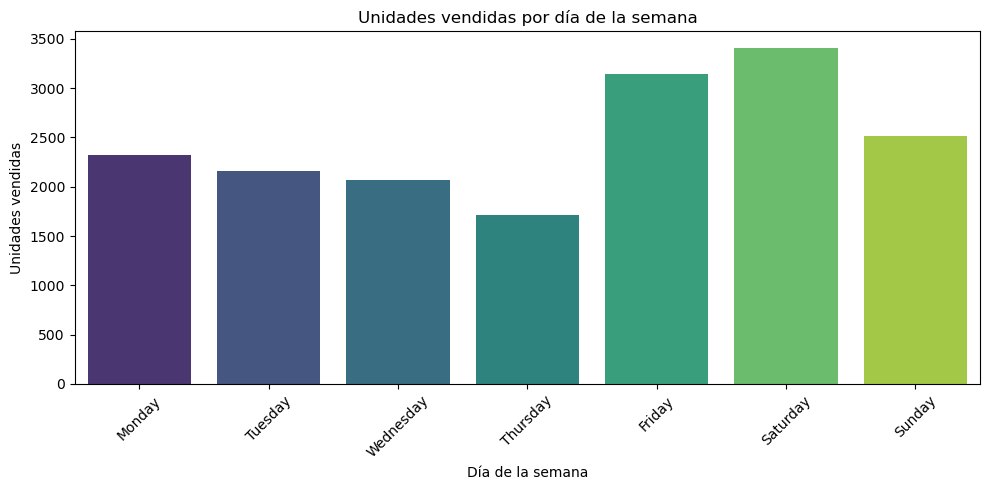

In [64]:
# 🤖 Suma de unidades vendidas por día de la semana
df = dataframe_unified.copy()
df['dia_semana'] = df['fecha'].dt.day_name()
ventas_por_dia_semana = df.groupby('dia_semana')['unidades_vendidas'].sum().reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
], fill_value=0)
plt.figure(figsize=(10,5))
sns.barplot(x=ventas_por_dia_semana.index, y=ventas_por_dia_semana.values, palette='viridis')
plt.title('Unidades vendidas por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Suma de unidades vendidas por categoría
Visualización de la suma de unidades vendidas agrupadas por categoría.

In [ ]:
# 🤖 Suma de unidades vendidas por categoría (optimizado)
ventas_por_categoria = dataframe_unified.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6), dpi=80)
ax = sns.barplot(x=ventas_por_categoria.index, y=ventas_por_categoria.values, 
                 hue=ventas_por_categoria.index, palette='Greys', legend=False)

# Añadir etiquetas con números absolutos en cada barra
for i, (categoria, valor) in enumerate(zip(ventas_por_categoria.index, ventas_por_categoria.values)):
    ax.text(i, valor, str(int(valor)), ha='center', va='bottom', fontweight='bold')

plt.title('Unidades vendidas por categoría', fontsize=14)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Unidades vendidas', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

### Suma de unidades vendidas por subcategoría
Visualización de la suma de unidades vendidas agrupadas por subcategoría.

In [ ]:
# 🤖 Suma de unidades vendidas por subcategoría
df = dataframe_unified.copy()
ventas_por_subcategoria = df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False)
plt.figure(figsize=(14,6))
sns.barplot(x=ventas_por_subcategoria.index, y=ventas_por_subcategoria.values, palette='mako')
plt.title('Unidades vendidas por subcategoría')
plt.xlabel('Subcategoría')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Suma de unidades vendidas por producto (Top productos)
Visualización de los productos con mayor cantidad de unidades vendidas.

In [ ]:
# 🤖 Top productos por unidades vendidas
df = dataframe_unified.copy()
top_n = 15
ventas_por_producto = df.groupby(['producto_id','nombre'])['unidades_vendidas'].sum().sort_values(ascending=False).head(top_n).reset_index()
plt.figure(figsize=(12,6))
sns.barplot(x='nombre', y='unidades_vendidas', data=ventas_por_producto, palette='rocket')
plt.title(f'Top {top_n} productos por unidades vendidas')
plt.xlabel('Producto')
plt.ylabel('Unidades vendidas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Densidad de distribución de precios (nuestros vs Amazon)
Comparativa de la densidad de precios de venta propios frente a los precios de Amazon como referencia de la competencia.

In [ ]:
# 🤖 Densidad de distribución de precios: nuestros vs Amazon
df = dataframe_unified.copy()
plt.figure(figsize=(10,6))
sns.kdeplot(df['precio_venta'], label='Precio venta propio', fill=True, color='blue', alpha=0.5)
sns.kdeplot(df['Amazon'], label='Precio Amazon', fill=True, color='orange', alpha=0.5)
plt.title('Densidad de distribución de precios: propios vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

## Ingeniería de características temporales
Creación de variables temporales y de calendario para análisis avanzados:
- Variables básicas: año, mes, día del mes, día de la semana
- Indicadores festivos: es_festivo, es_fin_semana
- Eventos especiales: es_Black_Friday, es_Cyber_Monday
- Variables derivadas: trimestre, semana del año, número de días en el mes, es_puente
- Indicadores relativos: días_hasta_fin_mes, días_hasta_fin_trimestre

In [54]:
# 🤖 Crear variables temporales y de calendario
import holidays as hol
from dateutil.relativedelta import relativedelta

# Obtener calendario de festivos de España
spanish_holidays = hol.Spain()

# Crear copia del dataframe para las nuevas variables
df_temporal = dataframe_unified.copy()

# Variables básicas de fecha
df_temporal['año'] = df_temporal['fecha'].dt.year
df_temporal['mes'] = df_temporal['fecha'].dt.month
df_temporal['dia_mes'] = df_temporal['fecha'].dt.day
df_temporal['dia_semana'] = df_temporal['fecha'].dt.day_name()
df_temporal['dia_semana_num'] = df_temporal['fecha'].dt.dayofweek  # 0=lunes, 6=domingo

# Variables derivadas
df_temporal['trimestre'] = df_temporal['fecha'].dt.quarter
df_temporal['semana_ano'] = df_temporal['fecha'].dt.isocalendar().week
df_temporal['num_dias_mes'] = df_temporal['fecha'].dt.daysinmonth

# Indicadores de fin de semana
df_temporal['es_fin_semana'] = df_temporal['dia_semana_num'].isin([5, 6]).astype(int)

# Indicador de festivo
df_temporal['es_festivo'] = df_temporal['fecha'].apply(lambda x: 1 if x in spanish_holidays else 0)

# Variables de eventos especiales
# Black Friday: último viernes de noviembre
df_temporal['es_Black_Friday'] = 0
for year in df_temporal['año'].unique():
    noviembre = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
    black_friday_date = [d.date() for d in noviembre if d.weekday() == 4][-1]
    df_temporal.loc[df_temporal['fecha'].dt.date == black_friday_date, 'es_Black_Friday'] = 1

# Cyber Monday: primer lunes después del Black Friday
df_temporal['es_Cyber_Monday'] = 0
for year in df_temporal['año'].unique():
    noviembre = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
    black_friday_date = [d for d in noviembre if d.weekday() == 4][-1]
    cyber_monday_date = black_friday_date + pd.Timedelta(days=3)  # Miércoles después del BF
    df_temporal.loc[df_temporal['fecha'].dt.date == cyber_monday_date.date(), 'es_Cyber_Monday'] = 1

# Año nuevo, Navidad y días alrededor
df_temporal['es_Navidad'] = ((df_temporal['mes'] == 12) & (df_temporal['dia_mes'].isin([24, 25, 26]))).astype(int)
df_temporal['es_Ano_Nuevo'] = ((df_temporal['mes'] == 1) & (df_temporal['dia_mes'].isin([1, 2, 3]))).astype(int)
df_temporal['es_Verano'] = df_temporal['mes'].isin([7, 8]).astype(int)

# Indicador de puente (viernes previo a festivo o lunes posterior)
df_temporal['es_puente'] = 0
for idx, row in df_temporal.iterrows():
    fecha = row['fecha']
    fecha_anterior = fecha - pd.Timedelta(days=1)
    fecha_siguiente = fecha + pd.Timedelta(days=1)
    if (fecha_anterior in spanish_holidays or fecha_siguiente in spanish_holidays):
        if row['dia_semana_num'] in [4, 0]:  # viernes o lunes
            df_temporal.loc[idx, 'es_puente'] = 1

# Días hasta fin de mes
df_temporal['dias_hasta_fin_mes'] = (df_temporal['fecha'].dt.daysinmonth - df_temporal['dia_mes']).astype(int)

# Días hasta fin de trimestre
def dias_hasta_fin_trimestre(fecha):
    if fecha.quarter == 1:
        fin_trimestre = pd.Timestamp(f'{fecha.year}-03-31')
    elif fecha.quarter == 2:
        fin_trimestre = pd.Timestamp(f'{fecha.year}-06-30')
    elif fecha.quarter == 3:
        fin_trimestre = pd.Timestamp(f'{fecha.year}-09-30')
    else:
        fin_trimestre = pd.Timestamp(f'{fecha.year}-12-31')
    return (fin_trimestre - fecha).days

df_temporal['dias_hasta_fin_trimestre'] = df_temporal['fecha'].apply(dias_hasta_fin_trimestre)

# Días hasta fin de año
df_temporal['dias_hasta_fin_ano'] = df_temporal['fecha'].apply(lambda x: (pd.Timestamp(f'{x.year}-12-31') - x).days)

temporal_cols = ['año', 'mes', 'dia_mes', 'dia_semana', 'dia_semana_num', 'trimestre', 'semana_ano',
                 'num_dias_mes', 'es_fin_semana', 'es_festivo', 'es_Black_Friday', 'es_Cyber_Monday',
                 'es_Navidad', 'es_Ano_Nuevo', 'es_Verano', 'es_puente', 'dias_hasta_fin_mes',
                 'dias_hasta_fin_trimestre', 'dias_hasta_fin_ano']

# Mostrar resumen de las nuevas variables
print('=== RESUMEN DE VARIABLES TEMPORALES CREADAS ===')
print(f'Total de filas: {len(df_temporal)}')
print(f'Nuevas columnas creadas: {len(temporal_cols)}')

# Tabla con primeras filas
display(df_temporal[['fecha'] + temporal_cols].head(10))

# Distribución de eventos especiales
print(f'\nDistribución de eventos especiales:')
print(f'  Black Friday: {df_temporal["es_Black_Friday"].sum()} días')
print(f'  Cyber Monday: {df_temporal["es_Cyber_Monday"].sum()} días')
print(f'  Festivos: {df_temporal["es_festivo"].sum()} días')
print(f'  Fines de semana: {df_temporal["es_fin_semana"].sum()} días')
print(f'  Puentes: {df_temporal["es_puente"].sum()} días')
print(f'  Navidad: {df_temporal["es_Navidad"].sum()} días')
print(f'  Año Nuevo: {df_temporal["es_Ano_Nuevo"].sum()} días')
print(f'  Verano: {df_temporal["es_Verano"].sum()} días')

print('\n✓ Variables temporales creadas correctamente.')

=== RESUMEN DE VARIABLES TEMPORALES CREADAS ===
Total de filas: 3552
Nuevas columnas creadas: 19


,fecha,año,mes,dia_mes,dia_semana,dia_semana_num,trimestre,semana_ano,num_dias_mes,es_fin_semana,es_festivo,es_Black_Friday,es_Cyber_Monday,es_Navidad,es_Ano_Nuevo,es_Verano,es_puente,dias_hasta_fin_mes,dias_hasta_fin_trimestre,dias_hasta_fin_ano
0,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
1,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
2,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
3,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
4,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
5,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
6,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
7,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
8,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67
9,2021-10-25,2021,10,25,Monday,0,4,43,31,0,0,0,0,0,0,0,0,6,67,67



Distribución de eventos especiales:
  Black Friday: 96 días
  Cyber Monday: 72 días
  Festivos: 96 días
  Fines de semana: 984 días
  Puentes: 24 días
  Navidad: 0 días
  Año Nuevo: 0 días
  Verano: 0 días

✓ Variables temporales creadas correctamente.


In [56]:
# 🤖 Crear lags de unidades vendidas (1 a 7) y media móvil de 7 días, por año
# Copia del dataframe temporal

# Usamos df_temporal generado en la celda anterior

df_lags = df_temporal.copy()

# Ordenar por fecha para cada año
# (por si acaso no está ordenado)
df_lags = df_lags.sort_values(['año', 'fecha']).reset_index(drop=True)

# Crear lags y media móvil por año
for año in df_lags['año'].unique():
    mask = df_lags['año'] == año
    for lag in range(1, 8):
        df_lags.loc[mask, f'unidades_vendidas_lag{lag}'] = df_lags.loc[mask, 'unidades_vendidas'].shift(lag)
    df_lags.loc[mask, 'unidades_vendidas_ma7'] = df_lags.loc[mask, 'unidades_vendidas'].rolling(window=7).mean()

# Eliminar registros con nulos en cualquiera de las nuevas variables
lag_cols = [f'unidades_vendidas_lag{lag}' for lag in range(1,8)] + ['unidades_vendidas_ma7']
df_lags = df_lags.dropna(subset=lag_cols).reset_index(drop=True)

# Mostrar primeras filas para ver resultado
df_lags[['fecha', 'año', 'unidades_vendidas'] + lag_cols].head(10)

,fecha,año,unidades_vendidas,unidades_vendidas_lag1,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_ma7
0,2021-10-25,2021,2,2.0,2.0,2.0,2.0,2.0,10.0,6.0,3.142857
1,2021-10-25,2021,2,2.0,2.0,2.0,2.0,2.0,2.0,10.0,2.000000
2,2021-10-25,2021,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.000000
3,2021-10-25,2021,3,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.142857
4,2021-10-25,2021,3,3.0,2.0,2.0,2.0,2.0,2.0,2.0,2.285714
5,2021-10-25,2021,2,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.285714
6,2021-10-25,2021,2,2.0,3.0,3.0,2.0,2.0,2.0,2.0,2.285714
7,2021-10-25,2021,3,2.0,2.0,3.0,3.0,2.0,2.0,2.0,2.428571
8,2021-10-25,2021,2,3.0,2.0,2.0,3.0,3.0,2.0,2.0,2.428571
9,2021-10-25,2021,1,2.0,3.0,2.0,2.0,3.0,3.0,2.0,2.285714


In [61]:
# 🤖 Crear variable descuento porcentaje
# Fórmula: ((precio_venta - precio_base) / precio_base) * 100
# Usamos df_lags generado en la celda anterior

df_lags['descuento_porcentaje'] = ((df_lags['precio_venta'] - df_lags['precio_base']) / df_lags['precio_base']) * 100

# Mostrar primeras filas para ver resultado
df_lags[['fecha', 'producto_id', 'año', 'precio_base', 'precio_venta', 'descuento_porcentaje']].head(10)

,fecha,producto_id,año,precio_base,precio_venta,descuento_porcentaje
0,2021-10-25,PROD_008,2021,65,66.60,2.461538
1,2021-10-25,PROD_009,2021,400,392.31,-1.922500
2,2021-10-25,PROD_010,2021,175,174.92,-0.045714
3,2021-10-25,PROD_011,2021,45,44.32,-1.511111
4,2021-10-25,PROD_012,2021,55,55.05,0.090909
5,2021-10-25,PROD_013,2021,25,24.79,-0.840000
6,2021-10-25,PROD_014,2021,40,39.74,-0.650000
7,2021-10-25,PROD_015,2021,150,154.22,2.813333
8,2021-10-25,PROD_016,2021,830,821.29,-1.049398
9,2021-10-25,PROD_017,2021,95,96.56,1.642105


In [62]:
# 🤖 Crear variable precio_competencia y ratio_precio, y eliminar columnas de competidores
# Calcular precio promedio de Amazon, Decathlon y Deporvillage

df_lags['precio_competencia'] = df_lags[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)

# Crear ratio de nuestro precio respecto al precio promedio de la competencia
# ratio_precio = precio_venta / precio_competencia

df_lags['ratio_precio'] = df_lags['precio_venta'] / df_lags['precio_competencia']

# Eliminar las columnas de los competidores
cols_drop = ['Amazon', 'Decathlon', 'Deporvillage']
df_lags = df_lags.drop(columns=cols_drop)

# Mostrar primeras filas para ver resultado
df_lags[['fecha', 'producto_id', 'año', 'precio_venta', 'precio_competencia', 'ratio_precio']].head(10)

,fecha,producto_id,año,precio_venta,precio_competencia,ratio_precio
0,2021-10-25,PROD_008,2021,66.60,64.346667,1.035019
1,2021-10-25,PROD_009,2021,392.31,350.850000,1.118170
2,2021-10-25,PROD_010,2021,174.92,160.156667,1.092181
3,2021-10-25,PROD_011,2021,44.32,44.563333,0.994540
4,2021-10-25,PROD_012,2021,55.05,53.246667,1.033868
5,2021-10-25,PROD_013,2021,24.79,24.096667,1.028773
6,2021-10-25,PROD_014,2021,39.74,39.460000,1.007096
7,2021-10-25,PROD_015,2021,154.22,135.673333,1.136701
8,2021-10-25,PROD_016,2021,821.29,735.070000,1.117295
9,2021-10-25,PROD_017,2021,96.56,92.636667,1.042352


In [69]:
df_lags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3524 entries, 0 to 3523
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   fecha                     3524 non-null   datetime64[ns]
 1   producto_id               3524 non-null   object        
 2   nombre                    3524 non-null   object        
 3   categoria                 3524 non-null   object        
 4   subcategoria              3524 non-null   object        
 5   precio_base               3524 non-null   int64         
 6   es_estrella               3524 non-null   bool          
 7   unidades_vendidas         3524 non-null   int64         
 8   precio_venta              3524 non-null   float64       
 9   ingresos                  3524 non-null   float64       
 10  año                       3524 non-null   int32         
 11  mes                       3524 non-null   int32         
 12  dia_mes             

In [ ]:
# 🤖 Crear copias *_h y aplicar One-Hot Encoding sobre ellas
# Copiar columnas con sufijo _h
df_lags['nombre_h'] = df_lags['nombre']
df_lags['categoria_h'] = df_lags['categoria']
df_lags['subcategoria_h'] = df_lags['subcategoria']

# One-Hot Encoding (usamos prefijos que incluyan _h para distinguir)
ohe_cols = ['nombre_h','categoria_h','subcategoria_h']
df_ohe = pd.get_dummies(df_lags[ohe_cols].astype(str), prefix=['nombre_h','categoria_h','subcategoria_h'], dtype=int)

# Concatenar las columnas OHE al dataframe principal
df_lags = pd.concat([df_lags, df_ohe], axis=1)

# Comprobación rápida: mostrar las nuevas columnas OHE y primeras filas
print('Número de columnas OHE añadidas:', df_ohe.shape[1])
print('Ejemplo de columnas OHE (primeras 10):', df_ohe.columns.tolist()[:10])
df_lags[['fecha','producto_id','año'] + df_ohe.columns.tolist()[:10]].head()

In [73]:
# 🤖 Guardar `df_lags` (versión compacta)
from pathlib import Path

# Usamos df_temporal generado en la celda anterior

df_processed = df_lags.copy()

p=Path('../data/processed'); p.mkdir(parents=True, exist_ok=True); df_processed.to_csv(p/'df_processed.csv', index=False)
print('Guardado:', p/'df_processed.csv')


Guardado: ..\data\processed\df_processed.csv
